In [1]:
import numpy as np
import matplotlib.pyplot as plt
from myosuite.utils import gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.monitor import Monitor
import json
from stable_baselines3.common.vec_env import SubprocVecEnv
import glob
import os
import pandas as pd
import tqdm as tqdm
import imageio
import osl_imitation_env  # important : déclenche le register() au moment de l'import



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


MyoSuite:> Registering Myo Envs


# 1. Découverte automatique des runs disponibles

In [2]:

def list_available_runs(eval_logs_dir="./eval_logs"):
    """Liste tous les runs pour lesquels un fichier evaluations.npz existe."""
    runs = []
    for path in glob.glob(f"{eval_logs_dir}/*/evaluations.npz"):
        run_name = os.path.basename(os.path.dirname(path))
        runs.append(run_name)
    return sorted(runs)


def find_latest_checkpoint(run_name, checkpoints_dir="./checkpoints"):
    """Trouve le checkpoint le plus avancé (le plus de steps) pour un run donné."""
    pattern = f"{checkpoints_dir}/{run_name}/{run_name}_*_steps.zip"
    candidates = glob.glob(pattern)
    if not candidates:
        # repli sur best_model ou _final
        for fallback in [f"{checkpoints_dir}/{run_name}/best_model.zip",
                          f"{checkpoints_dir}/{run_name}_final.zip"]:
            if os.path.exists(fallback):
                return fallback
        return None
    # trie par nombre de steps extrait du nom de fichier
    candidates.sort(key=lambda p: int(p.split("_")[-2]))
    return candidates[-1]



# 2. Fonctions d'évaluation

In [3]:
def evaluate_model(model, n_episodes=20, seed=999):
    env = gym.make('myoChallengeOslRunFixed-v0', seed=seed)
    distances, lengths, falls = [], [], []

    for ep in range(n_episodes):
        obs, info = env.reset()
        terminated, truncated = False, False
        steps = 0
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            steps += 1

        distances.append(env.unwrapped.obs_dict["model_root_pos"][1])
        lengths.append(steps)
        falls.append(env.unwrapped._get_fallen_condition())

    env.close()
    return {
        "distance_mean": float(np.mean(distances)),
        "distance_std": float(np.std(distances)),
        "ep_len_mean": float(np.mean(lengths)),
        "ep_len_std": float(np.std(lengths)),
        "fall_rate": float(np.mean(falls)),
    }


def plot_training_comparison(run_names, eval_logs_dir="./eval_logs", savepath="training_comparison.png"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for run_name in run_names:
        npz_path = f"{eval_logs_dir}/{run_name}/evaluations.npz"
        if not os.path.exists(npz_path):
            print(f"[!] Pas de fichier trouvé pour {run_name} à {npz_path}")
            continue

        data = np.load(npz_path)
        timesteps = data["timesteps"]
        results = data["results"]
        ep_lengths = data["ep_lengths"]

        reward_mean = results.mean(axis=1)
        reward_std = results.std(axis=1)
        len_mean = ep_lengths.mean(axis=1)

        axes[0].plot(timesteps, reward_mean, label=run_name)
        axes[0].fill_between(timesteps, reward_mean - reward_std, reward_mean + reward_std, alpha=0.2)
        axes[1].plot(timesteps, len_mean, label=run_name)
        axes[2].plot(timesteps, reward_std, label=run_name)

    axes[0].set_title("Reward moyen (éval) au cours de l'entraînement")
    axes[0].set_xlabel("Pas d'entraînement"); axes[0].set_ylabel("Reward moyen ± écart-type")
    axes[1].set_title("Durée moyenne des épisodes (survie)")
    axes[1].set_xlabel("Pas d'entraînement"); axes[1].set_ylabel("Nombre de pas avant fin d'épisode")
    axes[2].set_title("Écart-type du reward (variance/consistance)")
    axes[2].set_xlabel("Pas d'entraînement"); axes[2].set_ylabel("Écart-type")

    for ax in axes:
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    plt.show()
    return fig

def summary_table(run_names, n_episodes=20, checkpoints_dir="./checkpoints", savepath="summary.csv"):
    """
    Pour chaque run : charge le dernier checkpoint dispo, évalue sur métriques neutres,
    et compile tout dans un tableau comparatif.
    """
    rows = []
    for run_name in run_names:
        ckpt_path = find_latest_checkpoint(run_name, checkpoints_dir)
        if ckpt_path is None:
            print(f"[!] Aucun checkpoint trouvé pour {run_name}")
            continue

        print(f"Évaluation de {run_name} (checkpoint: {os.path.basename(ckpt_path)})...")
        model = PPO.load(ckpt_path)
        metrics = evaluate_model(model, n_episodes=n_episodes)
        metrics["run_name"] = run_name
        metrics["checkpoint"] = os.path.basename(ckpt_path)
        rows.append(metrics)

    df = pd.DataFrame(rows).set_index("run_name")
    df.to_csv(savepath)
    print(df)
    return df


# 3. Résultats

In [4]:
print("Runs disponibles :", list_available_runs())
run_name = "baseline_sparse1_solved10_random_net256"


Runs disponibles : ['TEST_pipeline_check', 'baseline_sparse1_solved10', 'baseline_sparse1_solved10_20M', 'baseline_sparse1_solved10_init_net256_50M', 'baseline_sparse1_solved10_random_net256', 'baseline_sparse1_solved10_random_net256_1M', 'imitation_sparse1_solved10_qpos40', 'imitation_sparse1_solved10_qpos40_10M', 'imitation_sparse1_solved10_qpos40_20M', 'imitation_sparse1_solved10_qpos40_30M', 'shaped_sparse1_solved10_aM01_pM05', 'shaped_sparse1_solved10_aM05_pM2', 'shaped_sparse1_solved10_aM05_pM2_20M']


In [5]:
model = PPO.load("./checkpoints/baseline_sparse1_solved10_random_net256_final.zip")
# model = PPO.load("./checkpoints/imitation_sparse1_solved10_qpos40_final.zip")

print(model.policy)

ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=260, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=260, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=256, out_features=54, bias=True)
  (value_net): Linear(in_features=256, out_features=1, bias=True)
)


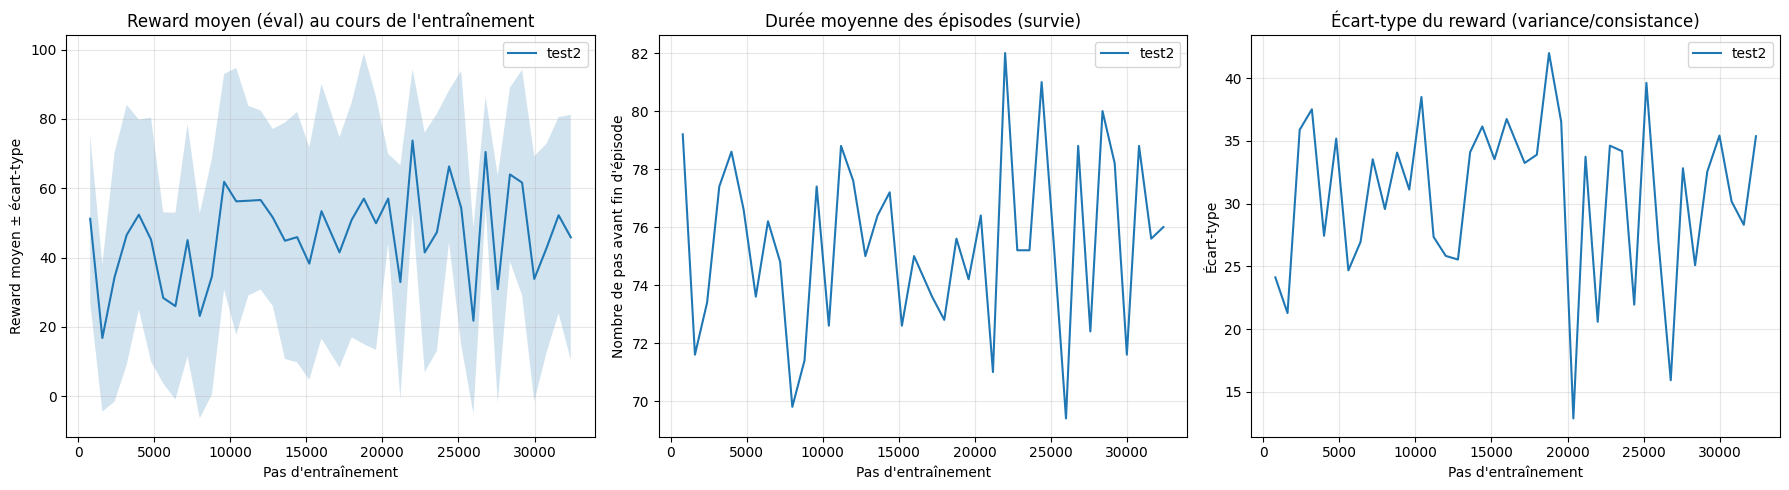

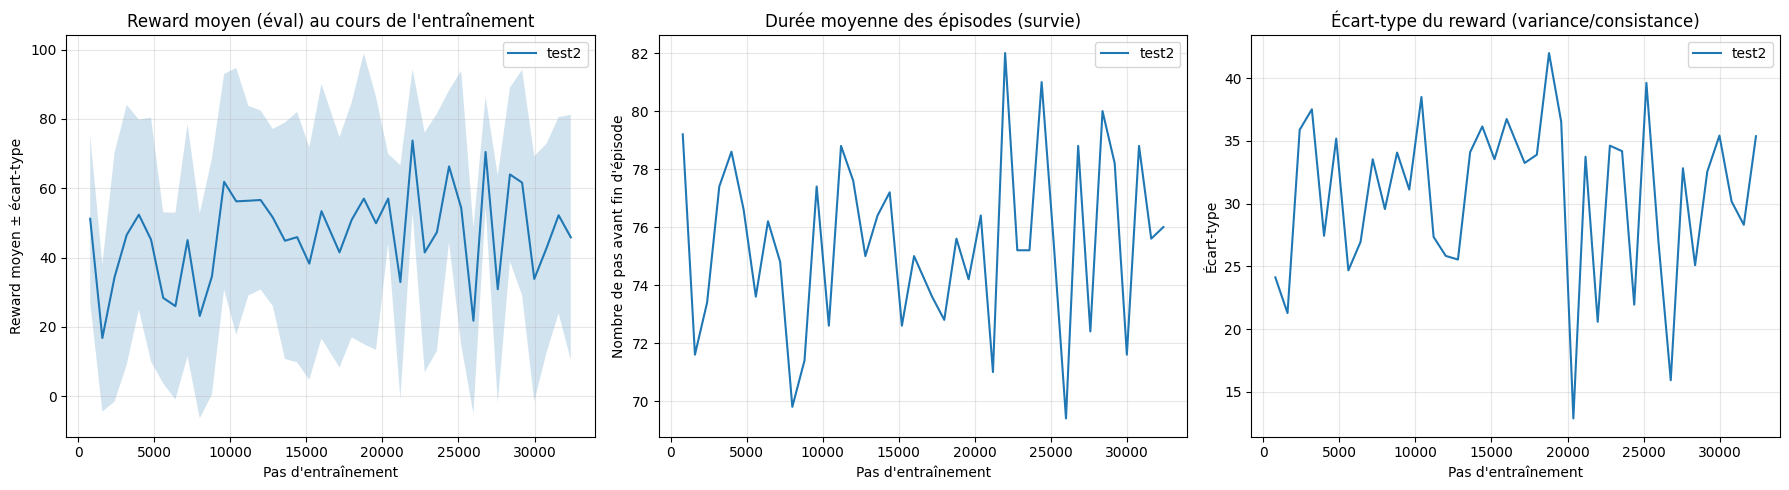

In [16]:
run_names = [
    # "baseline_sparse1_solved10_random_net256",
    # "imitation_sparse1_solved10_qpos40",
    "test2"
]

# Graphiques de progression pendant l'entraînement
plot_training_comparison(run_names)



In [7]:
# Tableau récapitulatif final (charge automatiquement le dernier checkpoint de chaque run)
df = summary_table(run_names, n_episodes=20)

Évaluation de baseline_sparse1_solved10_random_net256 (checkpoint: baseline_sparse1_solved10_random_net256_20000000_steps.zip)...
    MyoSuite: A contact-rich simulation suite for musculoskeletal motor control
        Vittorio Caggiano, Huawei Wang, Guillaume Durandau, Massimo Sartori, Vikash Kumar
        L4DC-2019 | https://sites.google.com/view/myosuite
    


c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


[!] Aucun checkpoint trouvé pour imitation_sparse1_solved10_qpos40_10M
[!] Aucun checkpoint trouvé pour imitation_sparse1_solved10_qpos40_20M
[!] Aucun checkpoint trouvé pour imitation_sparse1_solved10_qpos40_30M
Évaluation de imitation_sparse1_solved10_qpos40 (checkpoint: imitation_sparse1_solved10_qpos40_50000000_steps.zip)...
                                         distance_mean  distance_std  \
run_name                                                               
baseline_sparse1_solved10_random_net256      13.916554      0.249198   
imitation_sparse1_solved10_qpos40            13.429152      0.368381   

                                         ep_len_mean  ep_len_std  fall_rate  \
run_name                                                                      
baseline_sparse1_solved10_random_net256       197.95   63.377816       0.75   
imitation_sparse1_solved10_qpos40             242.95   40.376324       0.90   

                                                               

In [8]:
run_name = "imitation_sparse1_solved10_qpos40"
weighted_reward_keys = {"sparse": 1, "solved": 10, "qpos_imitation": 40}

# Utilise le "best_model" si dispo (meilleur checkpoint selon EvalCallback),
# sinon retombe sur le modèle final
best_model_path = f"./checkpoints/{run_name}/best_model"
final_model_path = f"./checkpoints/{run_name}_final"
model_path = best_model_path if os.path.exists(best_model_path) else final_model_path
print(f"Chargement du modèle depuis : {model_path}")

# env = gym.make('myoChallengeOslRunFixed-v0', weighted_reward_keys=weighted_reward_keys)
env = gym.make('myoOslImitation-v0', weighted_reward_keys=weighted_reward_keys)

model = PPO.load(model_path, env=env)

frames = []
all_rewards = []

for ep in tqdm.tqdm(range(5)):  # 5 épisodes, terrain randomisé par défaut
    obs, info = env.reset()
    ep_rewards = []
    terminated, truncated = False, False
    step_count = 0
    max_steps = 1000  # garde-fou, au cas où l'agent ne tombe jamais

    while not (terminated or truncated) and step_count < max_steps:
        action, _ = model.predict(obs, deterministic=True)

        # transparence du groupe de géométries 1 (comme dans le tutoriel officiel)
        geom_1_indices = np.where(env.unwrapped.mj_model.geom_group == 1)
        env.unwrapped.mj_model.geom_rgba[geom_1_indices, 3] = 0

        frame = env.unwrapped.mj_renderer.render_offscreen(
            width=400, height=400, camera_id=1
        )
        frames.append(frame)

        obs, reward, terminated, truncated, info = env.step(action)
        ep_rewards.append(reward)
        step_count += 1

    all_rewards.append(np.sum(ep_rewards))
    print(f"Episode {ep}: reward={np.sum(ep_rewards):.2f}, steps={step_count}")

env.close()

os.makedirs('videos', exist_ok=True)
imageio.mimwrite(f'videos/{run_name}.mp4', frames, fps=1.0 / env.unwrapped.dt)
print(f"Average reward: {np.mean(all_rewards):.2f} over {len(all_rewards)} episodes")

c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Chargement du modèle depuis : ./checkpoints/imitation_sparse1_solved10_qpos40_final
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\ST000082\Documents\Codes\myosuite\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
 20%|██        | 1/5 [00:18<01:12, 18.25s/it]

Episode 0: reward=134.75, steps=121


 40%|████      | 2/5 [00:39<00:59, 19.95s/it]

...

 80%|████████  | 4/5 [01:17<00:19, 19.59s/it]

Episode 3: reward=187.47, steps=119


100%|██████████| 5/5 [01:44<00:00, 20.83s/it]

Episode 4: reward=171.91, steps=172


Average reward: 175.62 over 5 episodes


In [9]:
env = gym.make('myoChallengeOslRunFixed-v0', reset_type="init")
obs, info = env.reset()
print("Fallen dès le reset ?", env.unwrapped._get_fallen_condition())
print("qpos au reset :", env.unwrapped.mj_data.qpos[:10])

# Fais quelques pas avec une action neutre (pas aléatoire) pour voir si ça tombe tout de suite
for i in range(20):
    obs, reward, terminated, truncated, info = env.step(np.zeros(env.action_space.shape))
    print(i, "reward:", reward, "terminated:", terminated, "fallen:", env.unwrapped._get_fallen_condition())
    if terminated or truncated:
        break

Fallen dès le reset ? 0
qpos au reset : [ 0.     55.      0.95    0.7074  0.      0.     -0.7068  0.      0.
  0.    ]
0 reward: -0.048481130964950284 terminated: True fallen: 0


### Récuperer des résultats à partir des log

In [10]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd

def load_tensorboard_data(log_dir):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    data = []
    for tag in ea.Tags()['scalars']:
        for event in ea.Scalars(tag):  # event est un ScalarEvent
            data.append({
                'tag': tag,
                'step': event.step,
                'value': event.value
            })
    return pd.DataFrame(data)

# Utilisation
df = load_tensorboard_data("./tb_logs/baseline_sparse1_solved10_random_net256_1M_1")
print(df.head())

                   tag   step       value
0  rollout/ep_len_mean  16384  168.586960
1  rollout/ep_len_mean  32768  170.009995
2  rollout/ep_len_mean  49152  169.830002
3  rollout/ep_len_mean  65536  168.800003
4  rollout/ep_len_mean  81920  169.210007


In [11]:
from tensorboard.backend.event_processing import event_accumulator

def list_tensorboard_tags(log_dir):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    return sorted(ea.Tags()['scalars'])  # Liste tous les tags scalaires

# Exemple pour ton run
tags = list_tensorboard_tags("./tb_logs/baseline_sparse1_solved10_random_net256_1M_1")
print("Tags disponibles :")
for tag in tags:
    print(f"  - {tag}")

Tags disponibles :
  - eval/mean_ep_length
  - eval/mean_reward
  - rollout/ep_len_mean
  - rollout/ep_rew_mean
  - time/fps
  - train/approx_kl
  - train/clip_fraction
  - train/clip_range
  - train/entropy_loss
  - train/explained_variance
  - train/learning_rate
  - train/loss
  - train/policy_gradient_loss
  - train/std
  - train/value_loss


In [12]:
def plot_training_comparison_tb(run_names, tb_logs_dir="./tb_logs", savepath="training_comparison.png"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for run_name in run_names:
        log_dir = f"{tb_logs_dir}/{run_name}"
        if not os.path.exists(log_dir):
            print(f"[!] Pas de dossier TensorBoard pour {run_name} à {log_dir}")
            continue

        # Charge les données TensorBoard
        df = load_tensorboard_data(log_dir)
        eval_df = df[df['tag'].str.contains('eval/')]

        # Pivot pour extraire les métriques par step
        pivot_df = eval_df.pivot(index='step', columns='tag', values='value')

        # Récupère les données (vérifie que les tags existent)
        timesteps = pivot_df.index.values
        reward_mean = pivot_df.get('eval/mean_reward', pivot_df.get('eval/reward_mean'))
        len_mean = pivot_df.get('eval/mean_ep_length', pivot_df.get('eval/episode_length'))

        if reward_mean is None:
            print(f"[!] Métriques manquantes pour {run_name}")
            continue

        # Trace
        axes[0].plot(timesteps, reward_mean, label=run_name)
        if len_mean is not None:
            axes[1].plot(timesteps, len_mean, label=run_name)

    # Configuration des axes (identique à l'original)
    axes[0].set_title("Reward moyen (éval) au cours de l'entraînement")
    axes[0].set_xlabel("Pas d'entraînement")
    axes[0].set_ylabel("Reward moyen ± écart-type")
    axes[1].set_title("Durée moyenne des épisodes (survie)")
    axes[1].set_xlabel("Pas d'entraînement")
    axes[1].set_ylabel("Nombre de pas avant fin d'épisode")
    axes[2].set_title("Écart-type du reward (variance/consistance)")
    axes[2].set_xlabel("Pas d'entraînement")
    axes[2].set_ylabel("Écart-type")

    for ax in axes:
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    # plt.savefig(savepath, dpi=150)
    plt.show()
    return fig

C:\Users\ST000082\AppData\Local\Temp\ipykernel_31736\4073885718.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


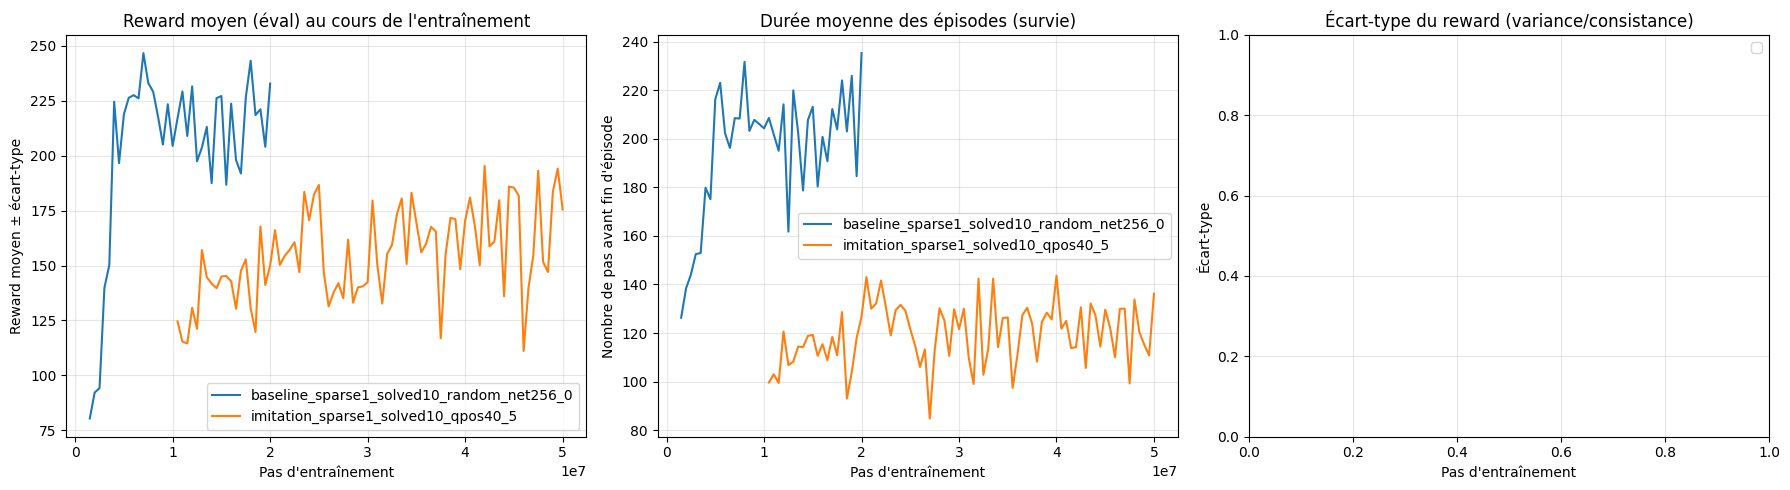

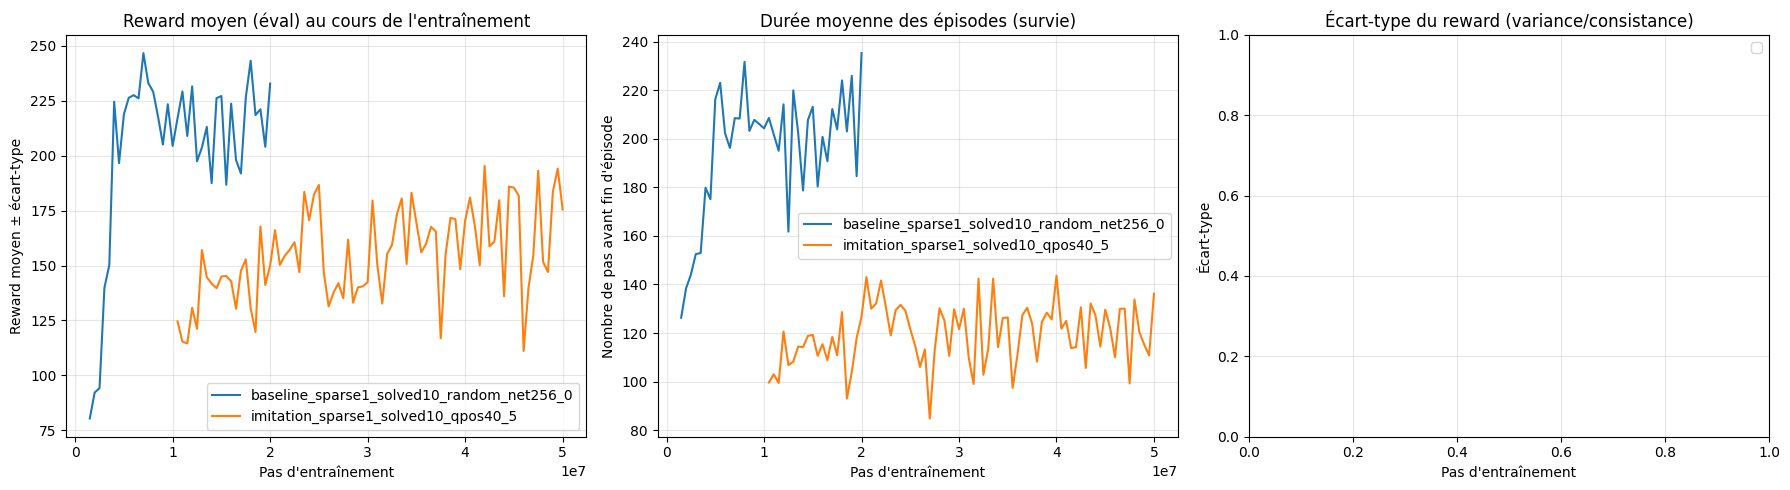

In [13]:
run_names = [
    "baseline_sparse1_solved10_random_net256_0",
    "imitation_sparse1_solved10_qpos40_5",
]


plot_training_comparison_tb(run_names, tb_logs_dir="./tb_logs", savepath="training_comparison.png")